# NASDAQ Ratio — Advancing/Declining als Einstiegssignal in alle 4 Indizes

Dieses Notebook untersucht, ob ein **hohes Niveau der Marktbreite am Börsenplatz
NASDAQ** ein gutes Einstiegssignal in die vier großen US-Aktienindizes gewesen
wäre.

**Wichtige Unterscheidung – Börsenplatz ≠ Index.** `NASDAQ` ist ein
*Handelsplatz*; an ihm werden viele Aktien gehandelt. Aus den dort steigenden und
fallenden Aktien (und ihrem Volumen) bilden wir zwei Marktbreite-Kennzahlen:

- **`stocks_ratio`** = Anteil der *gestiegenen* Aktien an allen bewegten Aktien (%)
- **`volume_ratio`** = Anteil des Volumens *gestiegener* Aktien am Gesamtvolumen (%)

Ein hoher Wert (viele Titel/viel Volumen steigen gleichzeitig) heißt
**Marktbreiten-Schub** – oft nach einem Ausverkauf. Wir prüfen: Wäre ein Einstieg
an Tagen mit **`stocks_ratio` bzw. `volume_ratio` ≥ 70 / 80 / 90 %** ein gutes
Signal gewesen – und zwar getrennt für **alle vier Indizes**:

| Index | Ticker |
|---|---|
| S&P 500 | ^GSPC |
| Dow Jones | ^DJI |
| NASDAQ-100 | ^NDX |
| Russell 2000 | ^RUT |

Bewertet wird die **Vorwärtsrendite** über **30 / 60 / 90 Handelstage**, ergänzt
um **Max Drawdown** und **Sharpe Ratio**, jeweils im Vergleich zur *Basisrate*
(Durchschnitt über alle Tage). Jede Kombination aus **Index × Ratio-Typ ×
Niveau × Horizont** wird einzeln ausgewertet.


## 1. Bibliotheken und Konfiguration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.figsize": (11, 4.5),
    "axes.titlesize": 12,
    "font.size": 10,
    "axes.edgecolor": "#8a8a8a",
})

# Einheitliche Farben je Index (klar unterscheidbar)
INDEX_COLORS = {
    "S&P 500":      "#2a78d6",
    "Dow Jones":    "#eb6834",
    "NASDAQ-100":   "#8a3fb0",
    "Russell 2000": "#0ca30c",
}
print("Bibliotheken geladen.")

Bibliotheken geladen.


**Was passiert hier?** Wir laden die Standard-Bibliotheken für Datenanalyse
(`pandas`/`numpy`), Grafik (`matplotlib`/`seaborn`) und Statistik (`scipy`).
Zusätzlich legen wir feste Farben je Index fest, damit alle Diagramme einheitlich
und gut lesbar sind.

In [2]:
# --- Konfiguration -----------------------------------------------------------
VENUE = "NASDAQ"                      # Börsenplatz dieses Notebooks
AUSREISSER_CAP = {"NYSE": 20000, "NASDAQ": 150000}[VENUE]  # Volumen-Ausreißergrenze

DATA_DIR = "../data"
AD_DIR = "../Advancing and Declining"

# Die vier Zielindizes mit ihren lokalen Kursdateien
INDIZES = {
    "S&P 500":      "sp500_raw.csv",
    "Dow Jones":    "dow_raw.csv",
    "NASDAQ-100":   "nasdaq100_raw.csv",
    "Russell 2000": "russell2000_raw.csv",
}

RATIO_TYPEN = ["stocks_ratio", "volume_ratio"]
NIVEAUS = [70, 80, 90]                 # Einstiegs-Schwellen in %
HORIZONTE = [30, 60, 90]               # Halteperioden in Handelstagen
MIN_SIGNALE = 30                       # ab hier gilt eine Zelle als belastbar

print(f"Börsenplatz: {VENUE}  |  Ausreißergrenze Volumen: {AUSREISSER_CAP:,}")

Börsenplatz: NASDAQ  |  Ausreißergrenze Volumen: 150,000


**Was passiert hier?** Das ist die einzige Stelle, die sich zwischen dem
NYSE- und dem NASDAQ-Notebook unterscheidet: der **Börsenplatz** und seine
Ausreißergrenze fürs Volumen. Außerdem legen wir die vier Zielindizes, die zwei
Ratio-Typen, die Schwellen (70/80/90 %) und die Halteperioden (30/60/90 Tage)
fest. `MIN_SIGNALE = 30` markiert später, welche Auswertungen genug Fälle haben,
um belastbar zu sein.

## 2. Daten laden und aufbereiten

### 2.1 Marktbreite am Börsenplatz NASDAQ

Wir laden für NASDAQ die vier Rohreihen *Advancing/Declining Stocks* und
*Advancing/Declining Volume*, entfernen einen bekannten Volumen-Ausreißer (ein
einmaliges technisches Ereignis) und berechnen daraus `stocks_ratio` und
`volume_ratio`.

In [3]:
def lade_marktbreite(venue: str, cap: int) -> pd.DataFrame:
    """Lädt die vier A/D-Rohreihen eines Börsenplatzes und bildet die Ratios."""
    def reihe(teil: str) -> pd.Series:
        roh = pd.read_csv(f"{AD_DIR}/{venue} {teil}.csv", parse_dates=["time"])
        roh = roh[roh["time"] >= pd.Timestamp("2006-12-31")]
        s = roh.set_index("time")["close"]
        s.index.name = "Date"
        return s.rename(teil.lower().replace(" ", "_"))

    df = pd.concat([reihe("Advancing Stocks"), reihe("Advancing Volume"),
                    reihe("Declining Stocks"), reihe("Declining Volume")], axis=1)
    df = df[~df.index.duplicated(keep="first")].sort_index()
    # Volumen-Ausreißer entfernen (einmaliges Ereignis, verzerrt die Ratio)
    df = df[(df["advancing_volume"] < cap) & (df["declining_volume"] < cap)]
    df["stocks_ratio"] = df["advancing_stocks"] / (df["advancing_stocks"] + df["declining_stocks"]) * 100
    df["volume_ratio"] = df["advancing_volume"] / (df["advancing_volume"] + df["declining_volume"]) * 100
    return df.dropna(subset=["stocks_ratio", "volume_ratio"])


breite = lade_marktbreite(VENUE, AUSREISSER_CAP)
print(f"{VENUE}: {len(breite):,} Handelstage von {breite.index.min().date()} "
      f"bis {breite.index.max().date()}")
display(breite[["stocks_ratio", "volume_ratio"]].describe().round(1))

NASDAQ: 4,736 Handelstage von 2007-09-28 bis 2026-08-10


,stocks_ratio,volume_ratio
count,4736.0,4736.0
mean,49.0,53.0
std,17.4,20.3
min,3.6,0.0
25%,35.7,38.9
50%,49.4,55.0
75%,62.4,68.5
max,88.9,97.6


**Was sagt uns das?** Die beiden Ratios schwanken um die 50 %: An einem
normalen Tag steigt etwa die Hälfte der Aktien/des Volumens. Werte deutlich über
70 % sind also eher selten und markieren Tage mit **ungewöhnlich breiter
Aufwärtsbewegung** – genau die Tage, deren Einstiegs-Qualität wir prüfen wollen.

### 2.2 Kursdaten der vier Indizes und Vorwärts-Kennzahlen

In [4]:
def forward_return(close: pd.Series, h: int) -> pd.Series:
    """Prozentuale Kursveränderung von heute bis h Handelstage später."""
    return close.shift(-h) / close - 1


def forward_max_drawdown(close: pd.Series, h: int) -> pd.Series:
    """Größter zwischenzeitlicher Rückgang vom laufenden Hoch im Fenster [t, t+h]."""
    werte = close.values
    out = np.full(len(werte), np.nan)
    for i in range(len(werte) - h):
        fenster = werte[i:i + h + 1]
        out[i] = (fenster / np.maximum.accumulate(fenster) - 1).min()
    return pd.Series(out, index=close.index)


index_daten = {}
for name, datei in INDIZES.items():
    px = pd.read_csv(f"{DATA_DIR}/{datei}", index_col="Date", parse_dates=True)[["Close"]].copy()
    for h in HORIZONTE:
        px[f"fwd_return_{h}d"] = forward_return(px["Close"], h)
        px[f"fwd_mdd_{h}d"] = forward_max_drawdown(px["Close"], h)
    index_daten[name] = px
    print(f"{name:14s}: {len(px):,} Handelstage ({px.index.min().date()} bis {px.index.max().date()})")

S&P 500       : 4,927 Handelstage (2007-01-03 bis 2026-08-04)
Dow Jones     : 4,931 Handelstage (2007-01-03 bis 2026-08-10)


NASDAQ-100    : 4,931 Handelstage (2007-01-03 bis 2026-08-10)


Russell 2000  : 4,931 Handelstage (2007-01-03 bis 2026-08-10)


**Was passiert hier?** Für jeden der vier Indizes berechnen wir zwei
Zukunfts-Kennzahlen: die **Vorwärtsrendite** (Kursgewinn nach 30/60/90 Tagen) und
den **Max Drawdown** (größter zwischenzeitlicher Rückschlag im selben Fenster).
Die Rendite zeigt die Chance, der Max Drawdown das Risiko des Einstiegs.

### 2.3 Signal-Kalender mit Index-Kennzahlen verknüpfen

In [5]:
# Je Index: Marktbreite (Börsenplatz-Kalender) mit den Vorwärts-Kennzahlen des
# Index verbinden. Beide teilen den US-Handelskalender, daher inner join per Datum.
merged = {}
for name, px in index_daten.items():
    m = breite[["stocks_ratio", "volume_ratio"]].join(
        px[["Close"] + [f"fwd_return_{h}d" for h in HORIZONTE]
                     + [f"fwd_mdd_{h}d" for h in HORIZONTE]], how="inner")
    merged[name] = m
    print(f"{name:14s}: {len(m):,} gemeinsame Handelstage")

S&P 500       : 4,731 gemeinsame Handelstage
Dow Jones     : 4,735 gemeinsame Handelstage
NASDAQ-100    : 4,735 gemeinsame Handelstage
Russell 2000  : 4,735 gemeinsame Handelstage


**Was passiert hier?** Das Signal entsteht am Börsenplatz (z. B. „70 % der
Aktien gestiegen"), die Wirkung messen wir aber am jeweiligen **Index**. Deshalb
führen wir beide über das Datum zusammen. So können wir für jeden Tag sagen: „An
diesem Signaltag – wie lief der Index danach?“

## 3. Verlauf der beiden Ratios mit Einstiegs-Schwellen

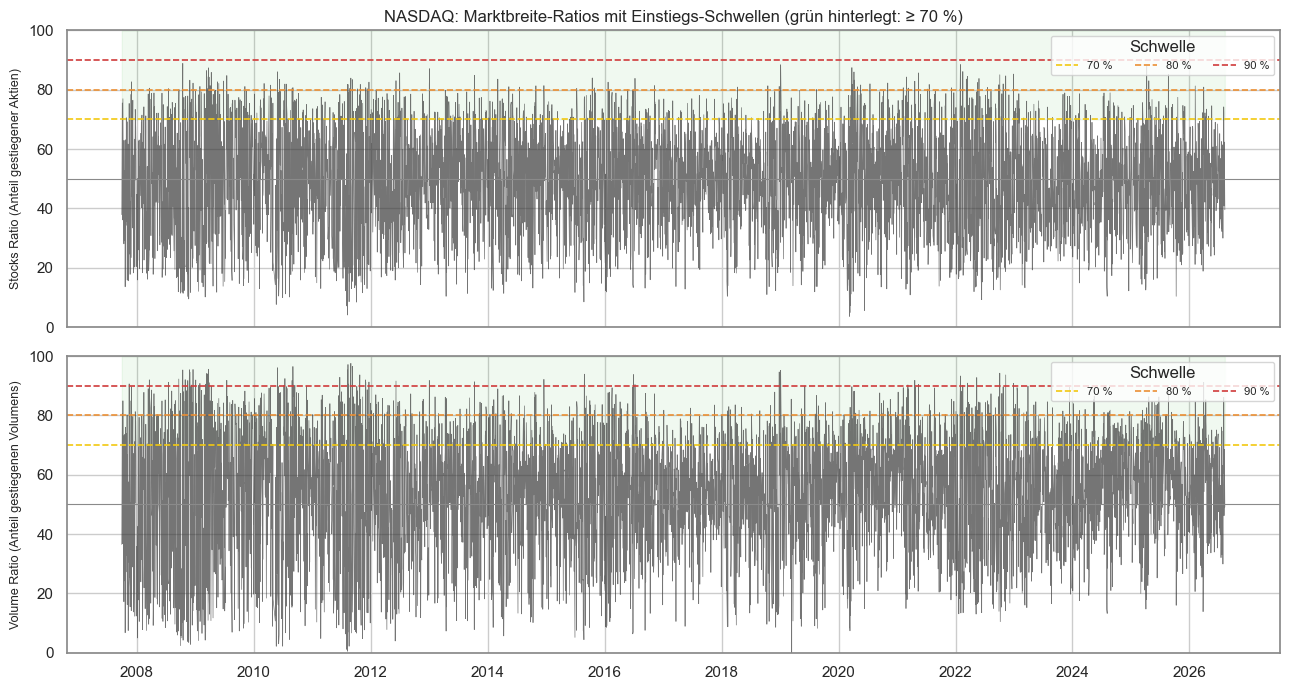

In [6]:
fig, achsen = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for achse, ratio, titel in zip(achsen, RATIO_TYPEN,
                               ["Stocks Ratio (Anteil gestiegener Aktien)",
                                "Volume Ratio (Anteil gestiegenen Volumens)"]):
    achse.plot(breite.index, breite[ratio], color="#3a3a3a", linewidth=0.5, alpha=0.7)
    for niv, farbe in zip(NIVEAUS, ["#f2c811", "#eb8f34", "#d03b3b"]):
        achse.axhline(niv, color=farbe, linestyle="--", linewidth=1.2, label=f"{niv} %")
    achse.axhline(50, color="#8a8a8a", linewidth=0.8)
    achse.fill_between(breite.index, 70, 100, color="#0ca30c", alpha=0.06)
    achse.set_ylabel(titel, fontsize=9)
    achse.set_ylim(0, 100)
    achse.legend(loc="upper right", ncol=3, fontsize=8, title="Schwelle")
achsen[0].set_title(f"{VENUE}: Marktbreite-Ratios mit Einstiegs-Schwellen (grün hinterlegt: ≥ 70 %)")
fig.tight_layout()
plt.show()

**Wie liest man das?** Jede Linie ist der Tagesverlauf einer Ratio; die
gestrichelten Linien sind die Schwellen 70/80/90 %. Der grün hinterlegte Bereich
(≥ 70 %) markiert die Einstiegs-Tage. Man erkennt: Solche Breiten-Schübe treten
gehäuft **nach** starken Markteinbrüchen auf – ein erstes Indiz dafür, dass sie
Erholungen einleiten könnten.

## 4. Kreuzauswertung: Einstiegssignal je Index / Niveau / Horizont

In [7]:
def sharpe_horizont(renditen: pd.Series, h: int) -> float:
    """Näherungsweise annualisierte Sharpe Ratio aus h-Tage-Vorwärtsrenditen (rf=0).
    Die Fenster überlappen sich (nicht unabhängig) – als Orientierungswert lesen."""
    r = renditen.dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    return r.mean() / r.std() * np.sqrt(252 / h)


zeilen = []
for index_name, m in merged.items():
    for ratio in RATIO_TYPEN:
        for niveau in NIVEAUS:
            signal = m[ratio] >= niveau
            for h in HORIZONTE:
                fr_sig = m.loc[signal, f"fwd_return_{h}d"].dropna()
                fr_all = m[f"fwd_return_{h}d"].dropna()
                md_sig = m.loc[signal, f"fwd_mdd_{h}d"].dropna()
                n = len(fr_sig)
                # Signifikanz: unterscheidet sich die Signal-Rendite von allen Tagen?
                p = (stats.mannwhitneyu(fr_sig, fr_all, alternative="two-sided").pvalue
                     if n >= 3 else np.nan)
                zeilen.append({
                    "Index": index_name, "Ratio": ratio, "Niveau": niveau, "Horizont": h,
                    "n": n,
                    "Rendite_Signal": fr_sig.mean() if n else np.nan,
                    "Rendite_Basis": fr_all.mean(),
                    "Mehrrendite": (fr_sig.mean() - fr_all.mean()) if n else np.nan,
                    "MaxDD_Signal": md_sig.mean() if n else np.nan,
                    "MaxDD_Basis": m[f"fwd_mdd_{h}d"].mean(),
                    "Sharpe_Signal": sharpe_horizont(fr_sig, h),
                    "Sharpe_Basis": sharpe_horizont(fr_all, h),
                    "p_Wert": p,
                    "belastbar": n >= MIN_SIGNALE,
                })

ergebnis = pd.DataFrame(zeilen)
print(f"{len(ergebnis)} Kombinationen (4 Indizes x 2 Ratios x 3 Niveaus x 3 Horizonte)")
print(f"davon belastbar (n >= {MIN_SIGNALE}): {int(ergebnis['belastbar'].sum())}")

72 Kombinationen (4 Indizes x 2 Ratios x 3 Niveaus x 3 Horizonte)
davon belastbar (n >= 30): 60


**Was passiert hier?** Das ist das Herzstück: Für **jede** Kombination aus
Index, Ratio-Typ, Schwelle (70/80/90 %) und Horizont (30/60/90 Tage) berechnen wir
die durchschnittliche Rendite nach dem Signal, die **Mehrrendite** gegenüber der
Basisrate (alle Tage), den Max Drawdown, die Sharpe Ratio und einen p-Wert
(Mann-Whitney-U: Ist der Renditeunterschied statistisch bedeutsam?). Insgesamt
72 Kombinationen je Börsenplatz.

In [8]:
# Übersichtstabelle (formatiert). "belastbar" = mindestens 30 Signaltage.
anzeige = ergebnis.copy()
for spalte in ["Rendite_Signal", "Rendite_Basis", "Mehrrendite", "MaxDD_Signal", "MaxDD_Basis"]:
    anzeige[spalte] = anzeige[spalte].map(lambda x: f"{x:+.1%}" if pd.notna(x) else "—")
for spalte in ["Sharpe_Signal", "Sharpe_Basis"]:
    anzeige[spalte] = anzeige[spalte].map(lambda x: f"{x:.2f}" if pd.notna(x) else "—")
anzeige["p_Wert"] = anzeige["p_Wert"].map(lambda x: ("<0,001" if x < 0.001 else f"{x:.3f}") if pd.notna(x) else "—")
anzeige["belastbar"] = anzeige["belastbar"].map(lambda x: "ja" if x else "nein")
display(anzeige)

,Index,Ratio,Niveau,Horizont,n,Rendite_Signal,Rendite_Basis,Mehrrendite,MaxDD_Signal,MaxDD_Basis,Sharpe_Signal,Sharpe_Basis,p_Wert,belastbar
0,S&P 500,stocks_ratio,70,30,624,+1.3%,+1.2%,+0.1%,-5.4%,-5.2%,0.66,0.61,0.262,ja
1,S&P 500,stocks_ratio,70,60,623,+2.6%,+2.4%,+0.2%,-7.8%,-7.6%,0.64,0.64,0.073,ja
2,S&P 500,stocks_ratio,70,90,618,+4.1%,+3.6%,+0.5%,-9.4%,-9.4%,0.67,0.64,0.100,ja
3,S&P 500,stocks_ratio,80,30,97,+2.6%,+1.2%,+1.4%,-5.7%,-5.2%,1.14,0.61,0.011,ja
4,S&P 500,stocks_ratio,80,60,97,+4.1%,+2.4%,+1.7%,-8.3%,-7.6%,0.83,0.64,0.021,ja
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,Russell 2000,volume_ratio,80,60,395,+2.1%,+2.3%,-0.2%,-11.9%,-10.2%,0.35,0.45,0.668,ja
68,Russell 2000,volume_ratio,80,90,393,+3.9%,+3.4%,+0.5%,-14.1%,-12.5%,0.45,0.45,0.325,ja
69,Russell 2000,volume_ratio,90,30,59,+2.7%,+1.1%,+1.5%,-9.5%,-7.0%,0.68,0.43,0.172,ja
70,Russell 2000,volume_ratio,90,60,59,+3.7%,+2.3%,+1.4%,-13.6%,-10.2%,0.51,0.45,0.206,ja


**Wie liest man die Tabelle?** Positive **Mehrrendite** heißt: Nach dem
Signal lief der Index besser als im Durchschnitt – ein Hinweis auf ein gutes
Einstiegssignal. Die Spalte **belastbar** warnt bei zu wenigen Signaltagen
(v. a. beim seltenen 90 %-Niveau): Solche Werte sind interessant, aber statistisch
unsicher und nicht überzubewerten.

### 4.1 Grafik 1 – Heatmap der Mehrrendite (Überblick)

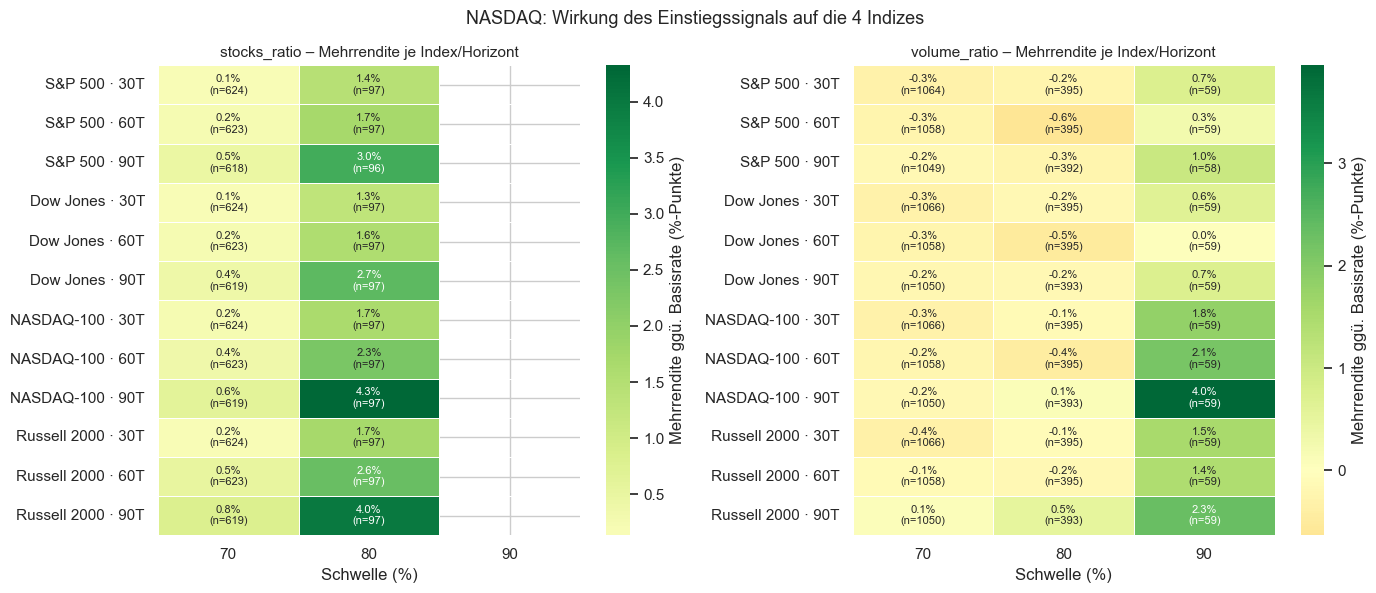

In [9]:
fig, achsen = plt.subplots(1, 2, figsize=(14, 6))
for achse, ratio in zip(achsen, RATIO_TYPEN):
    teil = ergebnis[ergebnis["Ratio"] == ratio].copy()
    teil["Zeile"] = teil["Index"] + " · " + teil["Horizont"].astype(str) + "T"
    pivot = teil.pivot(index="Zeile", columns="Niveau", values="Mehrrendite") * 100
    # Reihenfolge: nach Index, dann Horizont
    reihenfolge = [f"{ix} · {h}T" for ix in INDIZES for h in HORIZONTE]
    pivot = pivot.reindex(reihenfolge)
    n_pivot = teil.pivot(index="Zeile", columns="Niveau", values="n").reindex(reihenfolge)
    annot = pivot.round(1).astype(str) + "%\n(n=" + n_pivot.astype(int).astype(str) + ")"
    sns.heatmap(pivot, ax=achse, cmap="RdYlGn", center=0, annot=annot, fmt="",
                annot_kws={"fontsize": 8}, linewidths=0.6, linecolor="white",
                cbar_kws={"label": "Mehrrendite ggü. Basisrate (%-Punkte)"})
    achse.set_title(f"{ratio} – Mehrrendite je Index/Horizont", fontsize=11)
    achse.set_xlabel("Schwelle (%)")
    achse.set_ylabel("")
fig.suptitle(f"{VENUE}: Wirkung des Einstiegssignals auf die 4 Indizes", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man die Heatmap?** Jede Zelle ist eine Kombination aus Index und
Horizont (Zeile) und Schwelle (Spalte). **Grün = Mehrrendite** (Signal besser als
der Durchschnitt), **Rot = Minderrendite**. In Klammern steht die Zahl der
Signaltage (n). So sieht man auf einen Blick, wo das Signal wirkt und wo die
Datenbasis dünn ist.

### 4.2 Grafik 2 – Uplift-Balken je Index und Niveau (90-Tage-Horizont)

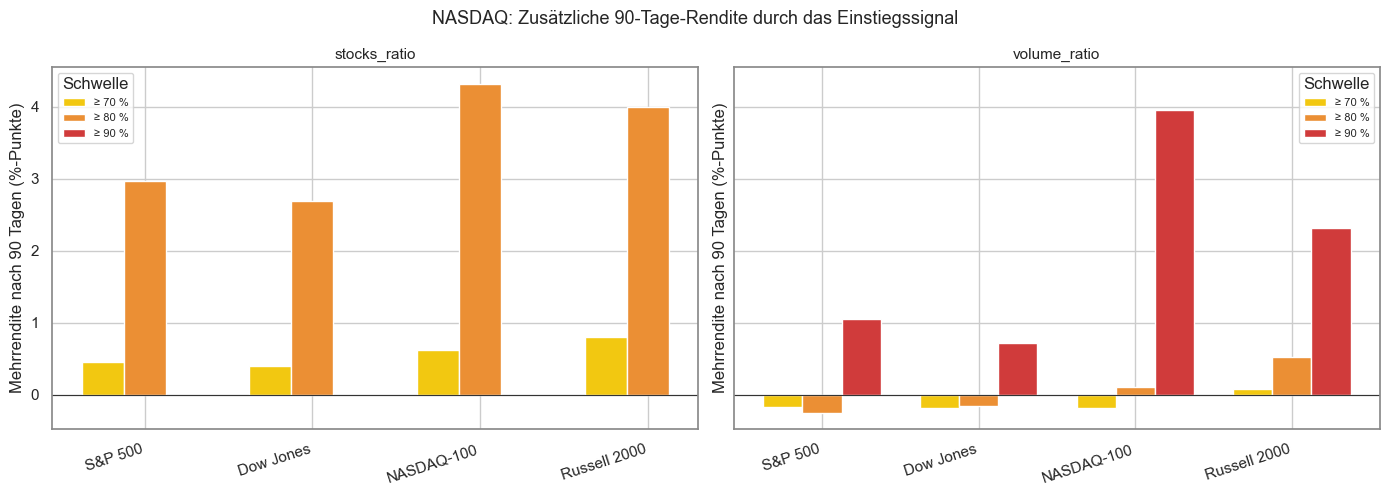

In [10]:
H_PLOT = 90
fig, achsen = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for achse, ratio in zip(achsen, RATIO_TYPEN):
    teil = ergebnis[(ergebnis["Ratio"] == ratio) & (ergebnis["Horizont"] == H_PLOT)]
    x = np.arange(len(INDIZES))
    breite_bar = 0.25
    for i, niv in enumerate(NIVEAUS):
        werte = [teil[(teil["Index"] == ix) & (teil["Niveau"] == niv)]["Mehrrendite"].values[0] * 100
                 for ix in INDIZES]
        achse.bar(x + (i - 1) * breite_bar, werte, breite_bar, label=f"≥ {niv} %",
                  color=["#f2c811", "#eb8f34", "#d03b3b"][i])
    achse.axhline(0, color="#333", linewidth=0.8)
    achse.set_xticks(x)
    achse.set_xticklabels(list(INDIZES), rotation=18, ha="right")
    achse.set_title(f"{ratio}", fontsize=11)
    achse.set_ylabel(f"Mehrrendite nach {H_PLOT} Tagen (%-Punkte)")
    achse.legend(title="Schwelle", fontsize=8)
fig.suptitle(f"{VENUE}: Zusätzliche {H_PLOT}-Tage-Rendite durch das Einstiegssignal", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man das?** Balken über null bedeuten: Der Einstieg nach dem
Signal hätte über 90 Tage **mehr** Rendite gebracht als ein beliebiger Tag.
Höhere Schwellen (rot, ≥ 90 %) sind selektiver – oft mit größerem Ausschlag, aber
auch weniger Fällen. Der Vergleich der vier Indizes zeigt, wo das Signal des
Börsenplatzes am besten „durchschlägt".

### 4.3 Grafik 3 – Verteilung der 90-Tage-Renditen (Signal vs. alle Tage)

C:\Users\jenni\AppData\Local\Temp\ipykernel_21184\1124806622.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}%"],
C:\Users\jenni\AppData\Local\Temp\ipykernel_21184\1124806622.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}%"],
C:\Users\jenni\AppData\Local\Temp\ipykernel_21184\1124806622.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}%"],
C:\Users\jenni\AppData\Local\Temp\ipykernel_21184\1124806622.py:

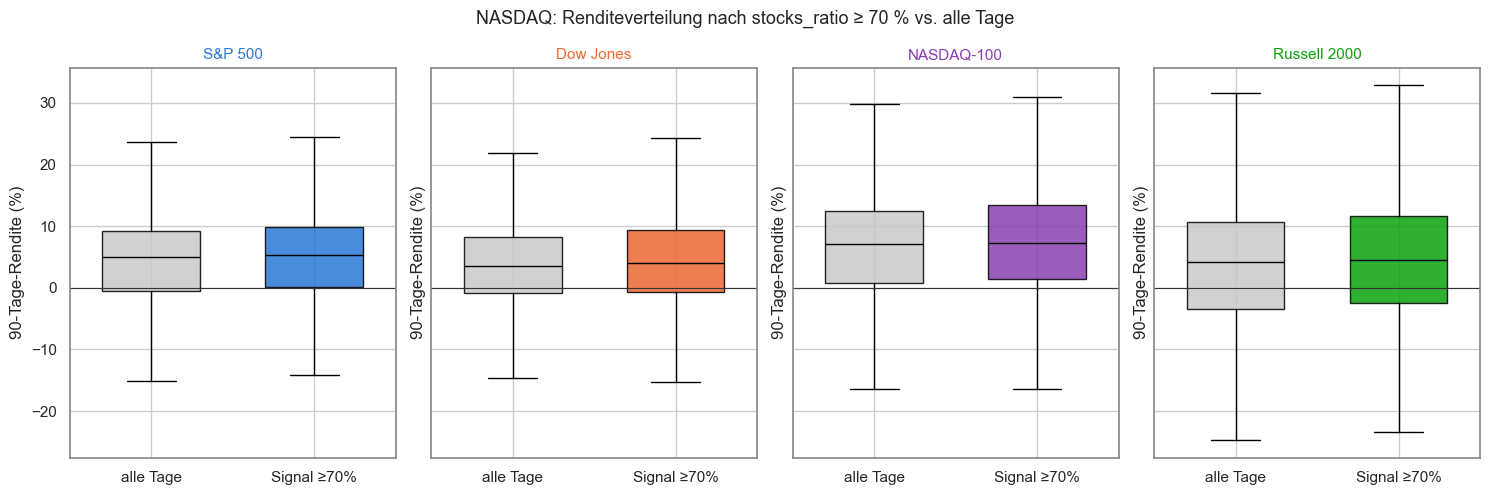

In [11]:
RATIO_BOX, NIVEAU_BOX, H_BOX = "stocks_ratio", 70, 90
fig, achsen = plt.subplots(1, 4, figsize=(15, 5), sharey=True)
for achse, (name, m) in zip(achsen, merged.items()):
    signal = m[RATIO_BOX] >= NIVEAU_BOX
    daten = [m[f"fwd_return_{H_BOX}d"].dropna() * 100,
             m.loc[signal, f"fwd_return_{H_BOX}d"].dropna() * 100]
    bp = achse.boxplot(daten, labels=["alle Tage", f"Signal ≥{NIVEAU_BOX}%"],
                       patch_artist=True, widths=0.6, showfliers=False)
    for patch, farbe in zip(bp["boxes"], ["#c9c9c9", INDEX_COLORS[name]]):
        patch.set_facecolor(farbe)
        patch.set_alpha(0.85)
    for med in bp["medians"]:
        med.set_color("black")
    achse.axhline(0, color="#333", linewidth=0.8)
    achse.set_title(name, fontsize=11, color=INDEX_COLORS[name])
    achse.set_ylabel(f"{H_BOX}-Tage-Rendite (%)")
fig.suptitle(f"{VENUE}: Renditeverteilung nach {RATIO_BOX} ≥ {NIVEAU_BOX} % vs. alle Tage", fontsize=13)
fig.tight_layout()
plt.show()

**Wie liest man Boxplots?** Die Box zeigt die mittleren 50 % der Renditen,
der Strich in der Box den Median. Liegt die Signal-Box **höher** als die
„alle Tage"-Box, war das Signal im Schnitt besser. Wichtig: Boxplots zeigen auch
die **Streuung** – ein höherer Mittelwert nützt wenig, wenn die Spanne riesig ist.
So wird sichtbar, wie verlässlich der Vorteil wirklich ist.

### 4.4 Grafik 4 – Event-Study: mittlerer Kursverlauf nach dem Signal

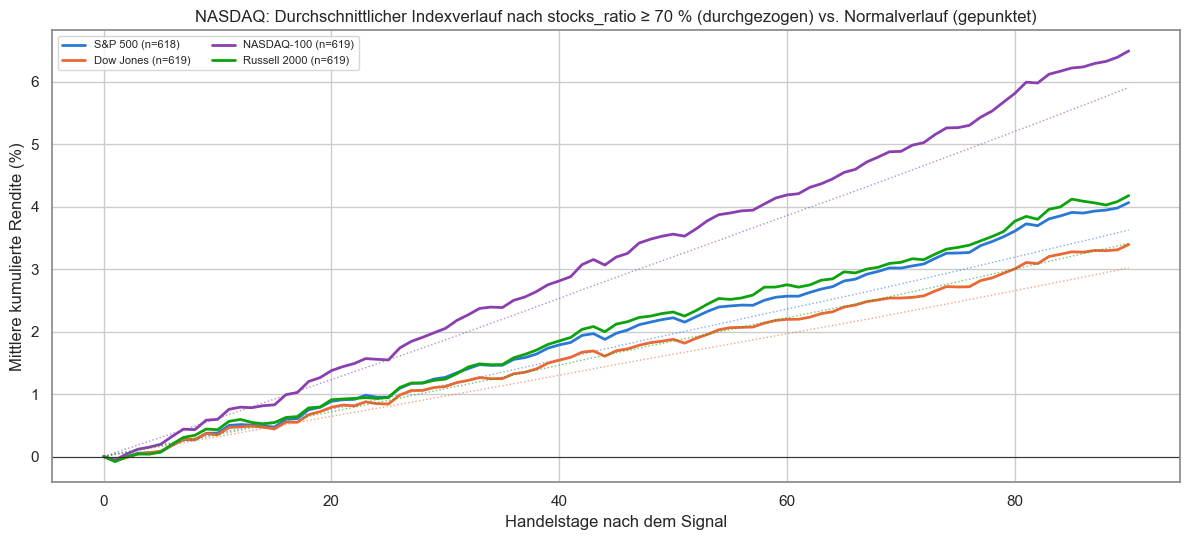

In [12]:
RATIO_EV, NIVEAU_EV, TAGE_EV = "stocks_ratio", 70, 90
fig, achse = plt.subplots(figsize=(12, 5.5))
for name, m in merged.items():
    close = m["Close"].values
    signal_idx = np.where((m[RATIO_EV] >= NIVEAU_EV).values)[0]
    pfade = [close[i:i + TAGE_EV + 1] / close[i] - 1
             for i in signal_idx if i + TAGE_EV < len(close)]
    if pfade:
        mittel = np.mean(pfade, axis=0) * 100
        achse.plot(range(TAGE_EV + 1), mittel, color=INDEX_COLORS[name], linewidth=2,
                   label=f"{name} (n={len(pfade)})")
    # Basisrate: mittlere Kursentwicklung über ALLE Starttage
    basis = [close[i:i + TAGE_EV + 1] / close[i] - 1 for i in range(len(close) - TAGE_EV)]
    achse.plot(range(TAGE_EV + 1), np.mean(basis, axis=0) * 100,
               color=INDEX_COLORS[name], linewidth=1, linestyle=":", alpha=0.6)
achse.axhline(0, color="#333", linewidth=0.8)
achse.set_xlabel("Handelstage nach dem Signal")
achse.set_ylabel("Mittlere kumulierte Rendite (%)")
achse.set_title(f"{VENUE}: Durchschnittlicher Indexverlauf nach {RATIO_EV} ≥ {NIVEAU_EV} % "
                f"(durchgezogen) vs. Normalverlauf (gepunktet)")
achse.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

**Wie liest man die Event-Study?** Jede durchgezogene Linie ist der
**gemittelte Kursverlauf** in den 90 Tagen nach einem Signal (Start = 0 %); die
gepunktete Linie derselben Farbe ist der Normalverlauf des Index über alle Tage.
Liegt die durchgezogene Linie über der gepunkteten, hat sich der Index nach dem
Signal überdurchschnittlich entwickelt – und man sieht, **ab wann** der Vorteil
entsteht.

## 5. Kernbefunde in einfachen Worten

In [13]:
bel = ergebnis[ergebnis["belastbar"]].copy()
positiv = bel[bel["Mehrrendite"] > 0]
anteil_positiv = len(positiv) / len(bel) if len(bel) else float("nan")
signifikant = bel[(bel["Mehrrendite"] > 0) & (bel["p_Wert"] < 0.05)]

print(f"Börsenplatz {VENUE} — belastbare Kombinationen: {len(bel)} von {len(ergebnis)}")
print(f"  davon mit positiver Mehrrendite: {len(positiv)} ({anteil_positiv:.0%})")
print(f"  davon zusätzlich statistisch signifikant (p<0,05): {len(signifikant)}")
print()
print("Stärkste belastbare Signale (nach Mehrrendite):")
top = bel.sort_values("Mehrrendite", ascending=False).head(5)
for _, r in top.iterrows():
    stern = "*" if r["p_Wert"] < 0.05 else " "
    print(f"  {stern} {r['Index']:14s} | {r['Ratio']:12s} ≥{r['Niveau']}% | {r['Horizont']}T: "
          f"{r['Mehrrendite']:+.1%} (Signal {r['Rendite_Signal']:+.1%} vs. Basis {r['Rendite_Basis']:+.1%}, "
          f"Sharpe {r['Sharpe_Signal']:.2f} vs. {r['Sharpe_Basis']:.2f}, n={r['n']})")
print("\n  * = statistisch signifikant (p<0,05)")

Börsenplatz NASDAQ — belastbare Kombinationen: 60 von 72
  davon mit positiver Mehrrendite: 39 (65%)
  davon zusätzlich statistisch signifikant (p<0,05): 13

Stärkste belastbare Signale (nach Mehrrendite):
  * NASDAQ-100     | stocks_ratio ≥80% | 90T: +4.3% (Signal +10.2% vs. Basis +5.9%, Sharpe 1.14 vs. 0.86, n=97)
  * Russell 2000   | stocks_ratio ≥80% | 90T: +4.0% (Signal +7.4% vs. Basis +3.4%, Sharpe 0.80 vs. 0.45, n=97)
  * NASDAQ-100     | volume_ratio ≥90% | 90T: +4.0% (Signal +9.9% vs. Basis +5.9%, Sharpe 1.05 vs. 0.86, n=59)
  * S&P 500        | stocks_ratio ≥80% | 90T: +3.0% (Signal +6.6% vs. Basis +3.6%, Sharpe 0.91 vs. 0.64, n=96)
  * Dow Jones      | stocks_ratio ≥80% | 90T: +2.7% (Signal +5.7% vs. Basis +3.0%, Sharpe 0.89 vs. 0.59, n=97)

  * = statistisch signifikant (p<0,05)


**Fazit für NASDAQ (dynamisch aus den Zahlen oben).** Der Ausdruck zeigt,
für wie viele der belastbaren Kombinationen das Signal eine **positive
Mehrrendite** gebracht hätte, und welche davon zusätzlich statistisch signifikant
sind. Als Faustregel gilt: Ein Marktbreiten-Schub am Börsenplatz NASDAQ ist dann
ein brauchbares Einstiegssignal, wenn die Mehrrendite **über mehrere Indizes,
Niveaus und Horizonte hinweg** positiv ist – Einzeltreffer bei seltenen
90 %-Signalen (kleines n) sollten dagegen vorsichtig interpretiert werden.

**Grenzen der Analyse.** Es handelt sich um eine **explorative** Auswertung
historischer Durchschnitte ohne Transaktionskosten; überlappende Zeitfenster
machen die p-Werte zu Orientierungswerten, nicht zu exakten Wahrscheinlichkeiten.
Die Ergebnisse sind ein Anhaltspunkt, keine Handelsgarantie.